In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

df = pd.read_csv(r"C:\Users\Dell\Documents\GitHub\DS111\Data\Gold\Gold_1.csv")

# Kiểm tra nhanh cấu trúc
print("Dataset Shape:", df.shape)
df.info()

# Insight Check: Dữ liệu có bị thiếu hụt ở các biến quan trọng (Ranks) không?
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (5623, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5623 entries, 0 to 5622
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country_Code                              5623 non-null   object 
 1   Year                                      5623 non-null   int64  
 2   Country_Name                              5623 non-null   object 
 3   AHS_Weighted_Average_Percent              5623 non-null   float64
 4   MFN_Weighted_Average_Percent              5623 non-null   float64
 5   AHS_Duty_Free_Tariff_Lines_Share_Percent  5623 non-null   float64
 6   has_RCA                                   5623 non-null   int64  
 7   cc_rank                                   5540 non-null   float64
 8   pv_rank                                   5571 non-null   float64
 9   rl_rank                                   5614 non-null   float64
 10  va_rank   

# 1. Logic Check

- Kiểm tra tính logic của Tariff_Gap và tính nhất quán của dữ liệu

In [2]:
# --- LOGIC CHECK 1: Tariff Gap Calculation ---
# Về lý thuyết: Tariff Gap thường là chênh lệch giữa MFN và AHS
# Insight: Nếu Gap != MFN - AHS, có thể do cơ chế tính trọng số (Weighted Average) khác nhau.
df['Calculated_Gap'] = df['MFN_Weighted_Average_Percent'] - df['AHS_Weighted_Average_Percent']
df['Gap_Discrepancy'] = df['Calculated_Gap'] - df['Tariff_Gap']

# Kiểm tra xem có sai lệch lớn không
discrepancy_check = df[df['Gap_Discrepancy'].abs() > 0.1]
print(f"Số lượng dòng có chênh lệch Gap (Logic Issue?): {len(discrepancy_check)}")
if len(discrepancy_check) > 0:
    print("Mẫu dữ liệu bị lệch:\n", discrepancy_check[['Country_Name', 'Year', 'MFN_Weighted_Average_Percent', 'AHS_Weighted_Average_Percent', 'Tariff_Gap', 'Calculated_Gap']].head())

# --- LOGIC CHECK 2: Percentages ---
# Kiểm tra xem có giá trị % nào nằm ngoài khoảng 0-100 (Logic Error)
invalid_percent = df[(df['AHS_Weighted_Average_Percent'] < 0) | (df['AHS_Weighted_Average_Percent'] > 100)]
print(f"\nSố dòng có % AHS không hợp lệ: {len(invalid_percent)}")

Số lượng dòng có chênh lệch Gap (Logic Issue?): 199
Mẫu dữ liệu bị lệch:
              Country_Name  Year  MFN_Weighted_Average_Percent  \
6                   Aruba  2010                          5.65   
19            Afghanistan  1998                         12.17   
41                 Angola  1996                          8.51   
105  United Arab Emirates  1996                         12.21   
106  United Arab Emirates  1998                          7.30   

     AHS_Weighted_Average_Percent  Tariff_Gap  Calculated_Gap  
6                            6.15         0.0           -0.50  
19                          12.58         0.0           -0.41  
41                          16.15         0.0           -7.64  
105                         30.79         0.0          -18.58  
106                          7.96         0.0           -0.66  

Số dòng có % AHS không hợp lệ: 0


# 3. Distribution Analysis (Skewness & Kurtosis)

- Phân tích phân phối để hiểu hành vi của dữ liệu (Skewness/Kurtosis)

Thống kê mô tả (Skewness & Kurtosis):
                               Skewness   Kurtosis
AHS_Weighted_Average_Percent  2.654590  12.636505
MFN_Weighted_Average_Percent  1.421907   3.964206
Tariff_Gap                    2.157430   9.691241
Log_Export                   -0.430019   1.679691
pv_rank                       0.225371  -1.130605
rl_rank                       0.170480  -1.159657


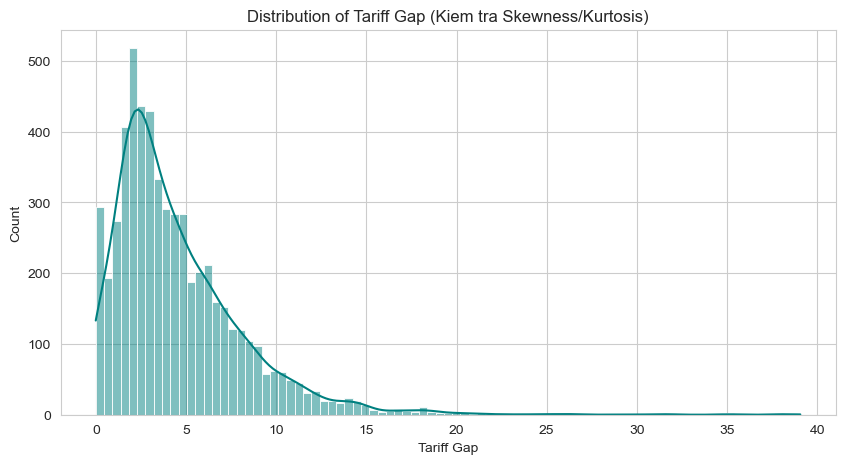

In [3]:
# Chọn các biến số quan trọng
numeric_vars = ['AHS_Weighted_Average_Percent', 'MFN_Weighted_Average_Percent', 
                'Tariff_Gap', 'Log_Export', 'pv_rank', 'rl_rank']

# Tính Skewness & Kurtosis
stats = pd.DataFrame({
    'Skewness': df[numeric_vars].skew(),
    'Kurtosis': df[numeric_vars].kurtosis()
})
print("Thống kê mô tả (Skewness & Kurtosis):\n", stats)

# --- VISUALIZATION & INSIGHT ---
# Vẽ biểu đồ phân phối cho Tariff_Gap
plt.figure(figsize=(10, 5))
sns.histplot(df['Tariff_Gap'], kde=True, color='teal')
plt.title('Distribution of Tariff Gap (Kiem tra Skewness/Kurtosis)')
plt.xlabel('Tariff Gap')
plt.show()

# === DOMAIN INSIGHT ===
# 1. High Kurtosis ở Tariff_Gap/AHS: Cho thấy dữ liệu có "Fat Tails" (đuôi dày). 
#    Nghĩa là có những quốc gia/năm áp thuế cực cao bất thường (outliers chính sách).
# 2. Skewness dương lớn: Phân phối lệch phải -> Đa số quốc gia có mức thuế thấp, 
#    chỉ một số ít có thuế rất cao (bảo hộ mậu dịch).
# 3. Governance Ranks (pv_rank, rl_rank): Kurtosis thấp (~ -1.2) là tốt, 
#    cho thấy phân phối Ranks trải đều (Uniform), phản ánh đúng tính chất xếp hạng percentile.

# 4. Correlation Matrix (Testing Hypotheses)

- Kiểm chứng các giả thuyết đưa ra: Governance vs Trade, Governance vs Gap

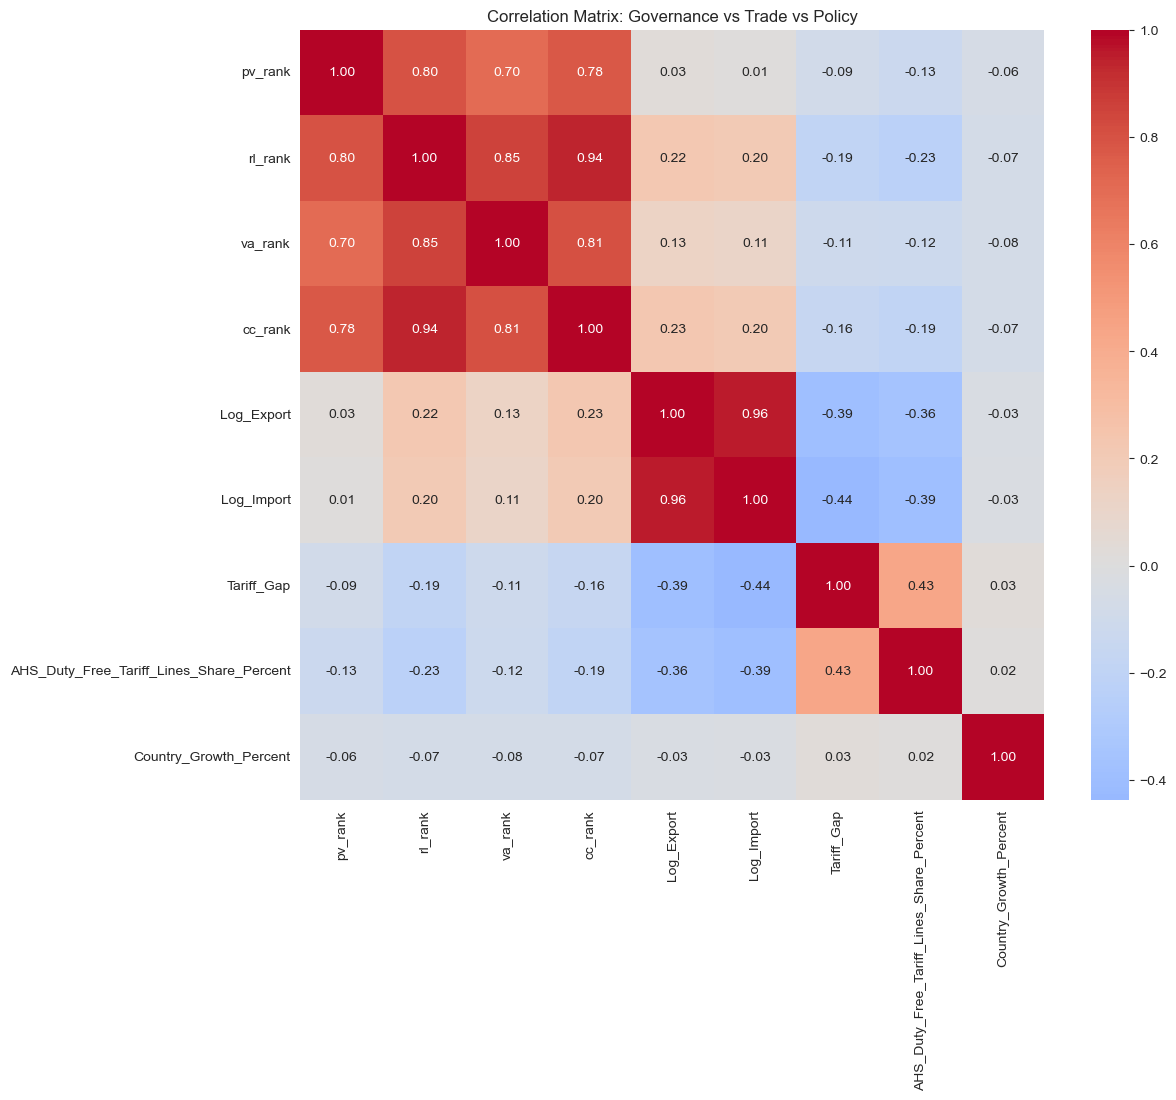

In [4]:
# Tạo danh sách các biến để check Correlation
corr_vars = ['pv_rank', 'rl_rank', 'va_rank', 'cc_rank', # Governance
             'Log_Export', 'Log_Import', # Trade
             'Tariff_Gap', 'AHS_Duty_Free_Tariff_Lines_Share_Percent', # Policy
             'Country_Growth_Percent'] # Macro

corr_matrix = df[corr_vars].corr()

# Vẽ Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Governance vs Trade vs Policy')
plt.show()

# === KIỂM CHỨNG INSIGHT ===
# 1. Governance -> Trade (Export/Import): Check màu ô giao nhau giữa ranks và Log_Export.
#    (Kỳ vọng dương: Quan trị tốt -> Xuất khẩu tốt).
# 2. Governance -> Gap: Check ô giao nhau giữa ranks và Tariff_Gap.
#    (Kỳ vọng âm: Quan trị tốt -> Gap nhỏ, chính sách minh bạch).
# 3. Governance -> Duty Free: Check ô ranks vs AHS_Duty_Free...
#    (Kỳ vọng âm nhẹ hoặc dương tùy context GSP/FTA).

# 5. Deep Dive Visualization & Interaction

- Interaction giữa Governance và Gap

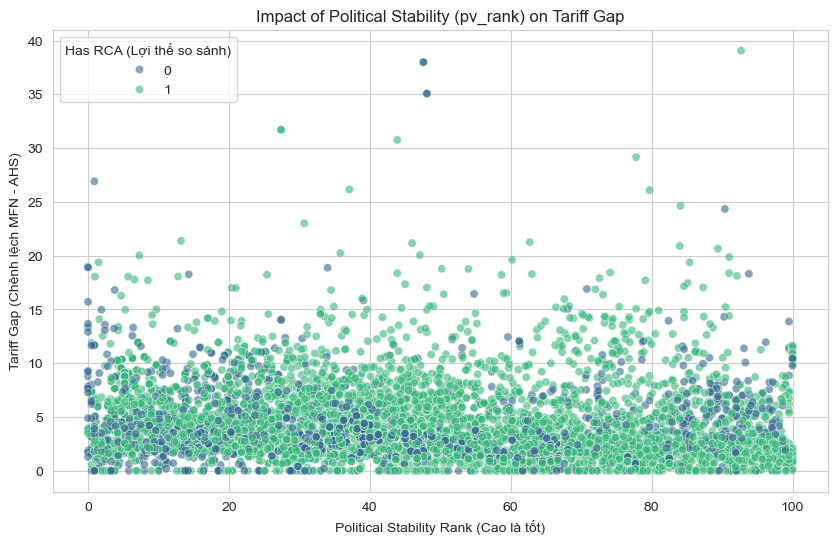

Correlation of Interaction Term with Export/Growth:
Interaction_Gov_Gap       1.000000
Log_Export               -0.307350
Country_Growth_Percent   -0.015071
Name: Interaction_Gov_Gap, dtype: float64


In [5]:
# --- VIZ: Scatter pv_rank vs Tariff_Gap (Color by RCA) ---
plt.figure(figsize=(10, 6))
# Lọc bớt nhiễu nếu cần, hoặc vẽ toàn bộ
sns.scatterplot(data=df, x='pv_rank', y='Tariff_Gap', 
                hue='has_RCA', alpha=0.6, palette='viridis')

plt.title('Impact of Political Stability (pv_rank) on Tariff Gap')
plt.xlabel('Political Stability Rank (Cao là tốt)')
plt.ylabel('Tariff Gap (Chênh lệch MFN - AHS)')
plt.legend(title='Has RCA (Lợi thế so sánh)')
plt.show()

# --- MODEL IDEA: Feature Engineering ---
# Tạo biến tương tác (Interaction Term) cho đồ án
# Ý nghĩa: Đo lường xem Governance tốt có làm giảm tác động tiêu cực của Tariff Gap hay không.
df['Interaction_Gov_Gap'] = df['pv_rank'] * df['Tariff_Gap']

# Check tương quan của biến mới này với Growth hoặc Export
print("Correlation of Interaction Term with Export/Growth:")
print(df[['Interaction_Gov_Gap', 'Log_Export', 'Country_Growth_Percent']].corr()['Interaction_Gov_Gap'])

# === INSIGHT TỪ VIZ ===
# Nhìn vào Scatter plot:
# - Nếu các điểm tập trung ở góc dưới bên phải (High Rank, Low Gap):
#   -> Chứng minh giả thuyết: Nước quản trị tốt thường duy trì chênh lệch thuế thấp (ổn định).
# - Màu sắc (RCA): Nếu các điểm màu vàng (has_RCA=1) tập trung nhiều ở vùng High Rank:
#   -> Governance tốt hỗ trợ việc hình thành lợi thế so sánh.